<a href="https://colab.research.google.com/github/Parthav47/llm_calling/blob/main/llm_calling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Function to auto push to github

In [ ]:
!pip install google-generativeai python-dotenv -q

In [ ]:
import google.generativeai as genai
from google.colab import userdata
genai.configure(api_key=userdata.get('GEMINI_API_KEY'))

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
model = genai.GenerativeModel("gemini-2.5-flash")
response = model.generate_content("Explain about 2nd Law of newton of motion in simple terms.")
print(response.text)

Imagine you're trying to move something. Newton's Second Law helps us understand *how much* that something will speed up, slow down, or change direction.

Here's the simplest way to think about it:

**The Big Idea:**

**The more you push or pull something (force), the faster it will speed up or slow down (acceleration). BUT, the heavier that thing is (mass), the harder it is to make it speed up or slow down.**

Let's break it down with an easy formula:

**F = m * a**

*   **F** stands for **Force**: This is the push or pull you apply.
*   **m** stands for **Mass**: This is how much "stuff" an object has, or how heavy it is.
*   **a** stands for **Acceleration**: This means how quickly an object changes its speed or direction.

---

**In simple terms, this means two main things:**

1.  **More Force = More Acceleration (if mass stays the same):**
    *   If you kick a soccer ball gently, it speeds up a little.
    *   If you kick it hard (more force), it speeds up a lot more (more accele

***Prompt Engineering***

In [ ]:
#zero_shot=model.generate_content("Classify the review as positive, negative and neutral\n.'Reply with only the word, nothing else.'  Review:'The food was okay but the service is slow.'")
#print("ZERO-SHOT:\n",zero_shot.text)

#few_shot=model.generate_content(""""
'''Classify each review as Positive, Negative or Neutral. Reply with only the word.

Review: "Amazing food and great ambience!" → Positive
Review: "Worst experience ever, never coming back." → Negative
Review: "It was fine, nothing special." → Neutral
Review: "The food was okay but service was slow." → """)
print("FEW-SHOT:\n",few_shot.text)'''

cot = model.generate_content("""
Classify this review as Positive, Negative or Neutral.
Think step by step before giving your final answer.
Format your response as:
Reasoning: <your thinking>
Answer: <one word>

Review: "The food was okay but service was slow." """)
print("CHAIN-OF-THOUGH:\n",cot.text)

CHAIN-OF-THOUGH:
 Reasoning: The review states "The food was okay," which implies an acceptable but not exceptional experience, leaning towards neutral for food. However, it immediately follows with "but service was slow," which is a clear negative point. The word "but" often highlights a contrasting, and in this case, a problematic aspect. Slow service is generally considered a significant detractor from a dining experience. While not extremely negative, the explicit complaint about service outweighs the neutral comment about food, making the overall sentiment lean towards negative.

Answer: Negative


***System Prompting***

In [ ]:
response1 = model.generate_content("Review: 'The food is okay but service was slow'")
print("RESPONSE_WITHOUT_SYSTEM_PROMPT:\n",response1.text)

print("\n"+"="*50+"\n")

RESPONSE_WITHOUT_SYSTEM_PROMPT:
 This is a concise and common type of review that highlights two key aspects of a dining experience: food quality and service efficiency.

Here's a breakdown of what the review conveys:

1.  **Food Quality: "The food is okay"**
    *   **Meaning:** This is a neutral assessment. It implies the food isn't particularly bad or inedible, but it's also not exceptional, memorable, or outstanding. It meets basic expectations without impressing. Diners shouldn't expect a culinary delight, but rather something that fills a basic need.
    *   **Impact:** It won't attract foodies or those looking for a gourmet experience, but it might not deter someone looking for a simple, no-frills meal.

2.  **Service Quality: "but service was slow"**
    *   **Meaning:** This is a clear negative point. "Slow service" can mean long waits for seating, ordering, receiving food, getting refills, or receiving the bill. This often leads to frustration and can significantly detract fr

In [ ]:
#Fixing Daily Rate Limit
for m in genai.list_models(): #checking available models
  if "generateContent" in m.supported_generation_methods:
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-2.5-flash-lite-preview-09-2025
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2025

In [ ]:
import time

# handling rate limit in paid/free tier models
# Maintains request per minute and token per minute
def safe_generate(model,prompt,retries=5):
  wait = 10 #Initially waits 10 sec
  for attempts in range(retries):
    try:
      response=model.generate_content(prompt)
      return response
    except Exception as e:
      error =str(e)
      if "429" in error:
        print(f"Rate limit hit. Attempt {attempts+1}/{retries}. Waiting {wait}s...")
        time.sleep(wait)
        wait*=2
      elif "500" in error or "503" in error:
        print(f"Server Error. Waiting {wait}sec..")
        time.sleep(wait)
        wait*=2
      else:
        print(f"Error: {error}")
        raise e
  return None

model_pro=genai.GenerativeModel(model_name="gemini-2.0-flash-001",
                      system_instruction="""You are a sentiment analysis engine for a restaurant review platform.
                      Your job is to classify reviews strictly.
                      Rules:
                      - Reply only in JSON
                      - Keys: sentiment, confidence(high/medium/low), reason(max 10 words)
                      - Never add explanation outside the JSON""")
response2 = safe_generate(model_pro,"Review: 'The food is okay but service was slow'")
#response2 = model_pro.generate_content("Review: 'The food is okay but service was slow'")
print("RESPONSE_WITH_SYSTEM_PROMPT:\n",response2.text)

Rate limit hit. Attempt 1/5. Waiting 10s...


Rate limit hit. Attempt 2/5. Waiting 20s...


Rate limit hit. Attempt 3/5. Waiting 40s...


KeyboardInterrupt: 

In [ ]:
'''
# Shorter prompt = fewer input tokens = lower cost
# Be concise in your system prompt — every word costs money

# Bad — verbose, wastes tokens
system = """You are a very helpful and friendly sentiment analysis assistant
who carefully reads restaurant reviews and thoughtfully classifies them..."""

# Good — tight, same result, fewer tokens
system = """Classify restaurant reviews. Reply only in JSON:
{"sentiment": "", "confidence": "", "reason": ""}"""

'''
'''
What API parameters control

pythonresponse = model.generate_content(
    "Review: 'Food was great!'",
    generation_config=genai.GenerationConfig(
        max_output_tokens=100,   # hard cap on response length = controls cost
        temperature=0.1,         # lower = faster + more deterministic
        top_p=0.9,               # controls randomness
        top_k=40                 # limits token choices = slightly faster
    )
)
'''

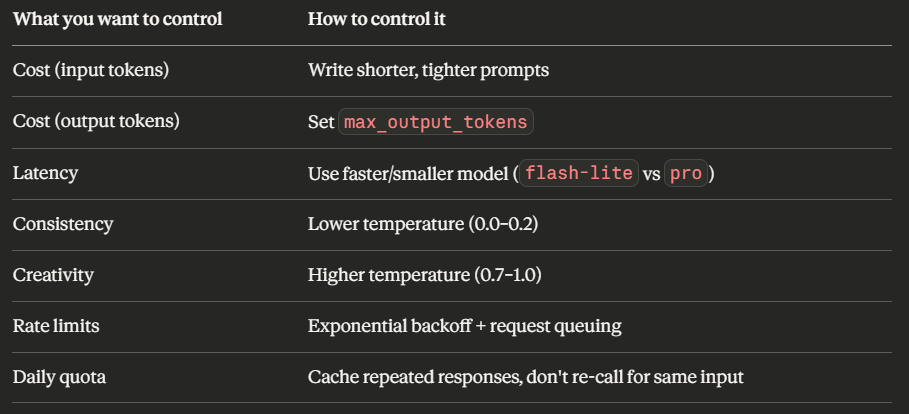

In [ ]:
'''
Caching is the most underrated cost saver — if 100 users ask the same thing, you call the API once and store the result:
pythoncache = {}

def cached_generate(model, prompt):
    if prompt in cache:
        print("Cache hit — no API call made")
        return cache[prompt]

    result = safe_generate(model, prompt)
    cache[prompt] = result
    return result
In a real product you'd use Redis or a database instead of a dictionary, but the concept is identical.
'''

Switching to groq api

In [ ]:
!pip install groq -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 3.4 MB/s eta 0:00:00


In [ ]:
from groq import Groq
from google.colab import userdata

client = Groq(api_key=userdata.get("GROQ_API_KEY"))

# according to the model the roleplay ability changes.
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {"role": "system", "content": """You are a sentiment analysis engine.
Reply ONLY in this exact JSON format, no deviations:
{"sentiment": "Positive/Negative/Neutral", "confidence": "high/medium/low", "reason": "max 10 words"}

Rules:
- confidence must be exactly one of: high, medium, low
- Never use numbers for confidence
- Never add anything outside the JSON"""},
        {"role": "user","content":"Review: 'The food is okay but service was slow'"}
        ]
)
print(response.choices[0].message.content)

{"sentiment": "Neutral", "confidence": "medium", "reason": "Mixed review given"}


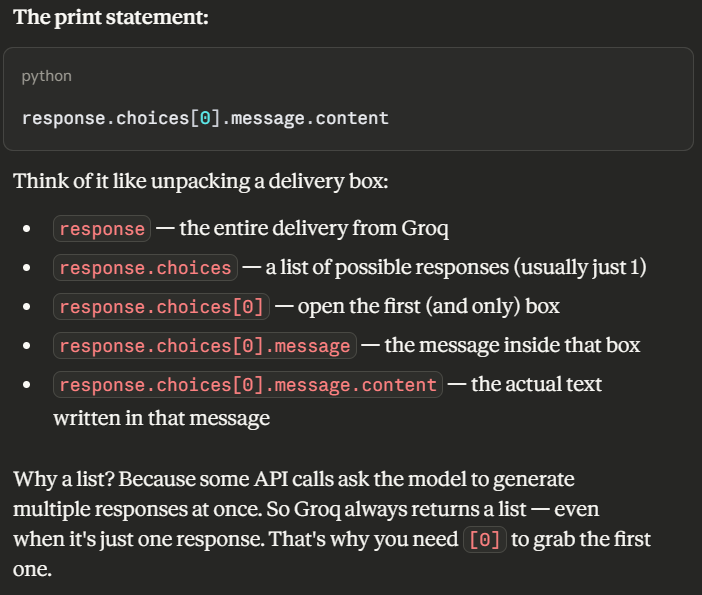

In [ ]:
!pip install groq -q
from groq import Groq
from google.colab import userdata

client = Groq(api_key=userdata.get("GROQ_API_KEY"))

# Without system prompt
response1 = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {"role": "user", "content": "Review: 'The food was okay but service was slow'"}
    ]
)
print("WITHOUT SYSTEM PROMPT:\n", response1.choices[0].message.content)
print("\n" + "="*50 + "\n")

# With system prompt
response2 = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {"role": "system", "content": """You are a sentiment analysis engine for a restaurant review platform.
Your job is to classify reviews strictly.
Rules:
- Reply only in JSON
- Keys: sentiment, confidence(high/medium/low), reason(max 10 words)
- Never add explanation outside the JSON"""},
        {"role": "user", "content": "Review: 'The food was okay but service was slow'"}
    ]
)
print("WITH SYSTEM PROMPT:\n", response2.choices[0].message.content)

WITHOUT SYSTEM PROMPT:
 **2.5/5 Stars**

The reviewer had a mediocre experience, with the food being just 'okay', implying it didn't exceed their expectations. However, the main issue was with the service, which was slow. This suggests that the staff may have been understaffed, inattentive, or disorganized, leading to a frustrating experience for the reviewer. Overall, the review suggests that the establishment needs to improve its service to provide a better overall experience for its customers.


WITH SYSTEM PROMPT:
 {"sentiment": "neutral", "confidence": "medium", "reason": "mixed experience"}


# ***Production Level Prompt***

In [ ]:
!pip install groq -q
import json
from groq import Groq
from google.colab import userdata

client = Groq(api_key=userdata.get("GROQ_API_KEY")) # Keeping the client object outside the func.
model = "llama-3.3-70b-versatile"

def get_sentiment(review_text):
  response = client.chat.completions.create(
      model=model,
      messages=[
          {"role":"system","content":"""Reply only in JSON with exactly these keys:
- sentiment: must be Positive, Negative, or Neutral
- confidence: must be high, medium, or low
- reason: max 10 words"""},
          {"role": "user", "content": f"Review: '{review_text}'"}
      ],
      response_format={"type":"json_object"}
  )

  raw = response.choices[0].message.content

  #JSON prasing and error handling
  try:
    parsed=json.loads(raw)
  except json.JSONDecodeError:
    return {"error":"Model returned invalid JSON","raw":raw}

  required_keys=["sentiment","confidence","reason"]
  for key in required_keys:
    if key not in parsed:
      return {"error":f"Missing key: {key}","raw":raw}

  valid_sentiments = ["positive" ,"negative","neutral"]
  valid_confidence = ["high","medium","low"]

  if parsed["sentiment"].lower() not in valid_sentiments:
    return {"Error":f"Invalid sentiment: {parsed['sentiment']}"}

  if parsed["confidence"].lower() not in valid_confidence:
    return {"Error":f"Invalid confidence: {parsed['confidence']}"}

  return parsed

reviews=[
    "Food was amazing, best meal of my life!",
    "Terrible experience, rude staff and cold food.",
    "It was okay, nothing special honestly."
]

for review in reviews:
  #Get model bad output and parse it properly and give insights on sentiments
  result = get_sentiment(review)
  print(f"Review:{review}")
  print(f"Result: {result}")


Review:Food was amazing, best meal of my life!
Result: {'sentiment': 'Positive', 'confidence': 'high', 'reason': 'Glowing review'}
Review:Terrible experience, rude staff and cold food.
Result: {'sentiment': 'Negative', 'confidence': 'high', 'reason': 'Rude staff'}
Review:It was okay, nothing special honestly.
Result: {'sentiment': 'Neutral', 'confidence': 'high', 'reason': 'Average experience'}


# extract_info() function

In [1]:
!pip install groq -q
import json
from google.colab import userdata
from groq import Groq

client = Groq(api_key=userdata.get("GROQ_API_KEY"))
model="llama-3.3-70b-versatile"

print("Ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 3.6 MB/s eta 0:00:00
Ready


In [9]:
# Test Paragrapgh
text = """
Elon Musk, the CEO of Tesla and SpaceX, announced yesterday in San Francisco
that the company plans to launch a new electric vehicle priced under $25,000
by mid-2026. The event was attended by over 500 investors and analysts.
Musk expressed confidence that this would outsell all competitors combined.
"""

text1="""
Elon Musk, the CEO of Tesla and SpaceX, announced yesterday in San Francisco
that the company plans to launch a new electric vehicle priced under $25,000
by mid-2026. The event was attended by over 500 investors and analysts.
Musk expressed confidence that this would outsell all competitors combined.
James Anderson from Morgan Stanley and Mary Barra, CEO of GM, were also
present and shared their thoughts on the announcement.
"""

response = client.chat.completions.create(
    model=model,
    messages=[
        {"role":"system","content":"""You are an information extraction engine.
Extract key information and reply ONLY in this exact JSON format:
{
  "main_topic": "one sentence describing what this is about",
  "people": ["list of people mentioned"],
  "organizations": ["list of organizations mentioned"],
  "locations": ["list of locations mentioned"],
  "key_facts": ["list of 3 most important facts"],
  "sentiment": "Positive/Negative/Neutral"
}"""},
        {"role":"user","content":f"Extract the information from this:{text1}"}
    ],
    response_format={"type":"json_object"}
)

parsed = json.loads(response.choices[0].message.content) # Gets result in one line

print(json.dumps(parsed, indent=2)) # Readable output

{
  "main_topic": "Elon Musk announces Tesla's plan to launch a new affordable electric vehicle",
  "people": [
    "Elon Musk",
    "James Anderson",
    "Mary Barra"
  ],
  "organizations": [
    "Tesla",
    "SpaceX",
    "Morgan Stanley",
    "GM"
  ],
  "locations": [
    "San Francisco"
  ],
  "key_facts": [
    "Tesla plans to launch a new electric vehicle under $25,000 by mid-2026",
    "The company aims to outsell all competitors combined with this new vehicle",
    "The announcement was attended by over 500 investors and analysts"
  ],
  "sentiment": "Positive"
}


In [14]:
# Extraction Engine
def extract_info(text):
  response = client.chat.completions.create(
    model=model,
    messages=[
        {"role":"system","content":"""You are an information extraction engine.
Extract key information and reply ONLY in this exact JSON format:
{
  "main_topic": "one sentence describing what this is about",
  "people": ["list of people mentioned"],
  "organizations": ["list of organizations mentioned"],
  "locations": ["list of locations mentioned"],
  "key_facts": ["list of 3 most important facts"],
  "sentiment": "Positive/Negative/Neutral"
}"""},
        {"role":"user","content":f"Extract the information from this:{text}"}
    ],
    response_format={"type":"json_object"}
)

  raw = response.choices[0].message.content

  try:
    parsed = json.loads(raw)
  except json.JSONDecodeError:
    return {"error":"Invalid JSON format", "raw":raw}

  required_keys = ["main_topic","people","organizations","locations","key_facts","sentiment"]
  for key in required_keys:
    if key not in parsed:
      return {"error":"Key not found in raw","key":key, "raw":raw}

  return parsed

sample_texts = [
    """Sundar Pichai, CEO of Google, announced a $1 billion investment
    in AI infrastructure across data centers in Iowa and Oregon.
    The project will create 5,000 jobs by 2027.""",

    """Scientists at MIT and Stanford published a breakthrough study
    showing that daily coffee consumption reduces the risk of
    Alzheimer's disease by 30%. Dr. Sarah Chen led the research team.""",

    """The Indian cricket team, led by Rohit Sharma, defeated Australia
    by 6 wickets in the final ODI match held in Mumbai.
    Virat Kohli scored a brilliant century."""
]

for i, text in enumerate(sample_texts):
  print(f"\n---text{i+1}---")
  result = extract_info(text)
  print(json.dumps(result, indent=2))


---text1---
{
  "main_topic": "Google's $1 billion investment in AI infrastructure",
  "people": [
    "Sundar Pichai"
  ],
  "organizations": [
    "Google"
  ],
  "locations": [
    "Iowa",
    "Oregon"
  ],
  "key_facts": [
    "Google is investing $1 billion in AI infrastructure",
    "The investment will be across data centers in Iowa and Oregon",
    "The project will create 5,000 jobs by 2027"
  ],
  "sentiment": "Positive"
}

---text2---
{
  "main_topic": "A study by MIT and Stanford scientists found a link between coffee consumption and reduced risk of Alzheimer's disease",
  "people": [
    "Dr. Sarah Chen"
  ],
  "organizations": [
    "MIT",
    "Stanford"
  ],
  "locations": [],
  "key_facts": [
    "Daily coffee consumption reduces the risk of Alzheimer's disease by 30%",
    "The study was led by Dr. Sarah Chen",
    "The research was a collaborative effort between MIT and Stanford scientists"
  ],
  "sentiment": "Positive"
}

---text3---
{
  "main_topic": "The Indian c